In [ ]:
!pip -q install "gymnasium[box2d]" stable-baselines3[extra] pygame pyvirtualdisplay imageio imageio-ffmpeg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 7.4 MB/s eta 0:00:00


In [ ]:
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import gymnasium as gym
from gymnasium.wrappers import RecordVideo

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy

from IPython.display import HTML, display
from base64 import b64encode

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
env = gym.make("BipedalWalker-v3")
obs, info = env.reset()

print("Observation shape:", obs.shape)
print("Action space:", env.action_space)
print("Observation space:", env.observation_space)

env.close()

Observation shape: (24,)
Action space: Box(-1.0, 1.0, (4,), float32)
Observation space: Box([-3.1415927 -5.        -5.        -5.        -3.1415927 -5.
 -3.1415927 -5.        -0.        -3.1415927 -5.        -3.1415927
 -5.        -0.        -1.        -1.        -1.        -1.
 -1.        -1.        -1.        -1.        -1.        -1.       ], [3.1415927 5.        5.        5.        3.1415927 5.        3.1415927
 5.        5.        3.1415927 5.        3.1415927 5.        5.
 1.        1.        1.        1.        1.        1.        1.
 1.        1.        1.       ], (24,), float32)


<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type swigvarlink has no __module__ attribute


In [ ]:
os.makedirs("models", exist_ok=True)
os.makedirs("videos", exist_ok=True)
os.makedirs("logs", exist_ok=True)

In [ ]:
train_env = gym.make("BipedalWalker-v3")
train_env = Monitor(train_env)

In [ ]:
model = PPO(
    policy="MlpPolicy",
    env=train_env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    verbose=1,
    tensorboard_log="./logs/"
)

Using cpu device
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
model.learn(total_timesteps=10000)
model.save("models/ppo_bipedalwalker_test")

Logging to ./logs/PPO_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 486      |
|    ep_rew_mean     | -110     |
| time/              |          |
|    fps             | 807      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 526         |
|    ep_rew_mean          | -111        |
| time/                   |             |
|    fps                  | 651         |
|    iterations           | 2           |
|    time_elapsed         | 6           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.006925108 |
|    clip_fraction        | 0.0488      |
|    clip_range           | 0.2         |
|    entropy_loss         | -5.7        |
|    explained_variance   | 0.0179      |
|    l

In [ ]:
model.learn(total_timesteps=200000)
model.save("models/ppo_bipedalwalker_final")

Logging to ./logs/PPO_2
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 382      |
|    ep_rew_mean     | -110     |
| time/              |          |
|    fps             | 1012     |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 585          |
|    ep_rew_mean          | -111         |
| time/                   |              |
|    fps                  | 782          |
|    iterations           | 2            |
|    time_elapsed         | 5            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0055171326 |
|    clip_fraction        | 0.0228       |
|    clip_range           | 0.2          |
|    entropy_loss         | -5.69        |
|    explained_variance   | 0.455 

In [ ]:
eval_env = gym.make("BipedalWalker-v3")
eval_env = Monitor(eval_env)

mean_reward, std_reward = evaluate_policy(
    model,
    eval_env,
    n_eval_episodes=5,
    deterministic=True
)

print(f"Mean reward over 5 episodes: {mean_reward:.2f} ± {std_reward:.2f}")

eval_env.close()

Mean reward over 5 episodes: 105.36 ± 77.26


In [ ]:
video_env = gym.make("BipedalWalker-v3", render_mode="rgb_array")
video_env = RecordVideo(
    video_env,
    video_folder="videos",
    name_prefix="bipedal_demo",
    episode_trigger=lambda episode_id: True
)

obs, info = video_env.reset()
done = False
truncated = False
total_reward = 0

while not (done or truncated):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = video_env.step(action)
    total_reward += reward

video_env.close()
print("Recorded episode reward:", total_reward)

Recorded episode reward: 151.89854


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
video_files = glob.glob("videos/*.mp4")
video_files = sorted(video_files, key=os.path.getmtime)

latest_video = video_files[-1]
print("Showing:", latest_video)

mp4 = open(latest_video, "rb").read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

display(HTML(f"""
<video width=700 controls>
    <source src="{data_url}" type="video/mp4">
</video>
"""))

Showing: videos/bipedal_demo-episode-0.mp4


In [ ]:
test_env = gym.make("BipedalWalker-v3")
obs, info = test_env.reset()

done = False
truncated = False
episode_reward = 0
steps = 0

while not (done or truncated):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = test_env.step(action)
    episode_reward += reward
    steps += 1

test_env.close()

print("Test episode reward:", episode_reward)
print("Steps survived:", steps)

Test episode reward: 141.0452
Steps survived: 1600


In [ ]:
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def evaluate_bipedal_model(model, env_name="BipedalWalker-v3", n_episodes=20):
    rewards = []
    steps_list = []
    fall_count = 0
    success_count = 0

    for ep in range(n_episodes):
        env = gym.make(env_name)
        obs, info = env.reset()

        done = False
        truncated = False
        total_reward = 0
        steps = 0

        while not (done or truncated):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, truncated, info = env.step(action)

            total_reward += reward
            steps += 1

        env.close()

        rewards.append(total_reward)
        steps_list.append(steps)

        # simple fall condition
        if steps < 300 or total_reward < 0:
            fall_count += 1

        # simple success condition
        if total_reward >= 200:
            success_count += 1

    results = {
        "Average Reward": np.mean(rewards),
        "Best Reward": np.max(rewards),
        "Worst Reward": np.min(rewards),
        "Reward Std": np.std(rewards),
        "Average Steps Survived": np.mean(steps_list),
        "Max Steps Survived": np.max(steps_list),
        "Min Steps Survived": np.min(steps_list),
        "Fall Rate (%)": (fall_count / n_episodes) * 100,
        "Success Rate (%)": (success_count / n_episodes) * 100
    }

    return results, rewards, steps_list

In [ ]:
results, rewards, steps_list = evaluate_bipedal_model(
    model=model,
    n_episodes=20
)

results_df = pd.DataFrame([results])
results_df

,Average Reward,Best Reward,Worst Reward,Reward Std,Average Steps Survived,Max Steps Survived,Min Steps Survived,Fall Rate (%),Success Rate (%)
0,21.782314,125.910645,-79.270195,80.619263,1204.35,1600,437,55.0,0.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


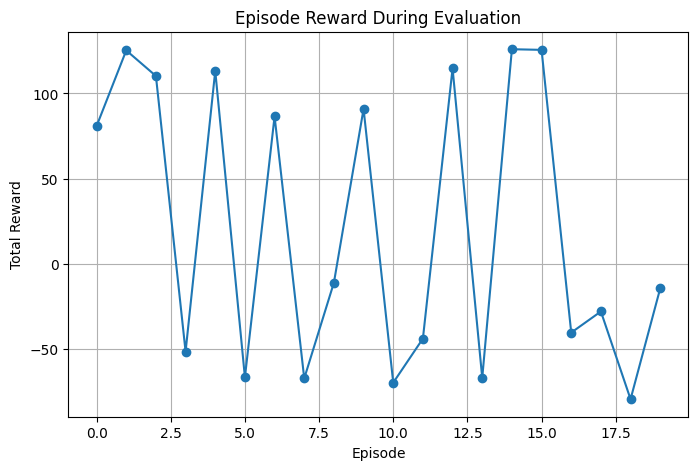

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(rewards, marker='o')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Episode Reward During Evaluation")
plt.grid(True)
plt.show()

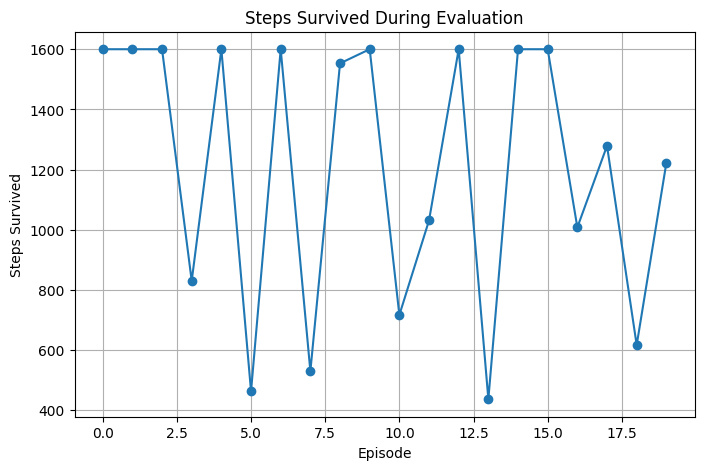

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(steps_list, marker='o')
plt.xlabel("Episode")
plt.ylabel("Steps Survived")
plt.title("Steps Survived During Evaluation")
plt.grid(True)
plt.show()

In [ ]:
import gymnasium as gym
import numpy as np
import pandas as pd

def evaluate_full_metrics(model, env_name="BipedalWalker-v3", n_episodes=20):

    rewards = []
    steps_list = []
    speeds = []
    energy_list = []
    stability_scores = []

    fall_count = 0
    success_count = 0

    for ep in range(n_episodes):
        env = gym.make(env_name)
        obs, info = env.reset()

        done = False
        truncated = False

        total_reward = 0
        steps = 0
        total_energy = 0
        position_progress = 0
        stability_counter = 0

        prev_x = 0

        while not (done or truncated):
            action, _ = model.predict(obs, deterministic=True)

            # energy = sum of absolute torques (actions)
            total_energy += np.sum(np.abs(action))

            obs, reward, done, truncated, info = env.step(action)

            total_reward += reward
            steps += 1

            # walking progress (x-axis movement)
            current_x = obs[0]  # hull x position
            position_progress += abs(current_x - prev_x)
            prev_x = current_x

            # stability → if torso angle small
            angle = obs[2]
            if abs(angle) < 0.2:
                stability_counter += 1

        env.close()

        rewards.append(total_reward)
        steps_list.append(steps)

        # speed = distance / steps
        speed = position_progress / (steps + 1e-5)
        speeds.append(speed)

        energy_list.append(total_energy)

        # stability score = % time balanced
        stability_scores.append(stability_counter / steps)

        # fall condition
        if steps < 300 or total_reward < 0:
            fall_count += 1

        # success condition
        if total_reward >= 200:
            success_count += 1

    results = {
        "Average Reward": np.mean(rewards),
        "Episode Length (avg steps)": np.mean(steps_list),
        "Walking Speed (avg)": np.mean(speeds),
        "Energy Consumption (avg)": np.mean(energy_list),
        "Training Convergence (reward std)": np.std(rewards),
        "Success Rate (%)": (success_count / n_episodes) * 100,
        "Fall Rate (%)": (fall_count / n_episodes) * 100,
        "Stability Score (avg)": np.mean(stability_scores)
    }

    return pd.DataFrame([results]), rewards, steps_list

In [ ]:
metrics_df, rewards, steps = evaluate_full_metrics(model, n_episodes=20)
metrics_df

,Average Reward,Episode Length (avg steps),Walking Speed (avg),Energy Consumption (avg),Training Convergence (reward std),Success Rate (%),Fall Rate (%),Stability Score (avg)
0,15.814084,1156.75,0.030884,2148.114258,82.671501,0.0,55.0,0.683216


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import gymnasium as gym
import numpy as np
from stable_baselines3 import TD3
from stable_baselines3.common.noise import NormalActionNoise

In [ ]:
train_env = gym.make("BipedalWalker-v3")

In [ ]:
n_actions = train_env.action_space.shape[-1]

action_noise = NormalActionNoise(
    mean=np.zeros(n_actions),
    sigma=0.1 * np.ones(n_actions)
)

In [ ]:
td3_model = TD3(
    policy="MlpPolicy",
    env=train_env,
    action_noise=action_noise,
    learning_rate=1e-3,
    buffer_size=100000,
    learning_starts=10000,
    batch_size=256,
    tau=0.005,
    gamma=0.99,
    train_freq=(1, "step"),
    gradient_steps=1,
    verbose=1,
    tensorboard_log="./td3_logs/"
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [ ]:
td3_model.learn(total_timesteps=800000)

Logging to ./td3_logs/TD3_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 846      |
|    ep_rew_mean     | -103     |
| time/              |          |
|    episodes        | 4        |
|    fps             | 1037     |
|    time_elapsed    | 3        |
|    total_timesteps | 3385     |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 652      |
|    ep_rew_mean     | -102     |
| time/              |          |
|    episodes        | 8        |
|    fps             | 1123     |
|    time_elapsed    | 4        |
|    total_timesteps | 5218     |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 841      |
|    ep_rew_mean     | -106     |
| time/              |          |
|    episodes        | 12       |
|    fps             | 991      |
|    time_elapsed    | 10       |
|    total_timesteps

KeyboardInterrupt: 

In [ ]:
td3_model.learn(
    total_timesteps=50000,
    reset_num_timesteps=False
)

Logging to ./td3_logs/TD3_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 854      |
|    ep_rew_mean     | 186      |
| time/              |          |
|    episodes        | 392      |
|    fps             | 27       |
|    time_elapsed    | 109      |
|    total_timesteps | 239998   |
| train/             |          |
|    actor_loss      | -18.4    |
|    critic_loss     | 0.479    |
|    learning_rate   | 0.001    |
|    n_updates       | 229997   |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 871      |
|    ep_rew_mean     | 201      |
| time/              |          |
|    episodes        | 396      |
|    fps             | 27       |
|    time_elapsed    | 235      |
|    total_timesteps | 243482   |
| train/             |          |
|    actor_loss      | -19.3    |
|    critic_loss     | 1.86     |
|    learning_rate   | 0.001    |
|    n_updates      

KeyboardInterrupt: 

In [ ]:
td3_model.save("td3_final")

In [ ]:
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
from IPython.display import HTML, display
from base64 import b64encode
import glob, os

video_env = gym.make("BipedalWalker-v3", render_mode="rgb_array")

video_env = RecordVideo(
    video_env,
    video_folder="td3_videos",
    name_prefix="td3_bipedal_demo",
    episode_trigger=lambda episode_id: True
)

obs, info = video_env.reset()
done = False
truncated = False
total_reward = 0

while not (done or truncated):
    action, _ = td3_model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = video_env.step(action)
    total_reward += reward

video_env.close()

print("TD3 Recorded episode reward:", total_reward)

TD3 Recorded episode reward: 299.4282


In [ ]:
video_files = glob.glob("td3_videos/*.mp4")
video_files = sorted(video_files, key=os.path.getmtime)

latest_video = video_files[-1]
print("Showing:", latest_video)

mp4 = open(latest_video, "rb").read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

display(HTML(f"""
<video width=700 controls>
    <source src="{data_url}" type="video/mp4">
</video>
"""))

Showing: td3_videos/td3_bipedal_demo-episode-0.mp4


In [ ]:
td3_metrics_df, td3_rewards, td3_steps = evaluate_full_metrics(
    td3_model,
    n_episodes=20
)

td3_metrics_df

,Average Reward,Episode Length (avg steps),Walking Speed (avg),Energy Consumption (avg),Training Convergence (reward std),Success Rate (%),Fall Rate (%),Stability Score (avg)
0,301.075256,907.85,0.010196,2245.180176,0.99874,100.0,0.0,0.06095


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
